<a href="https://colab.research.google.com/github/Ayden-DEMANOU/Convex-Hull/blob/main/Predictive_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

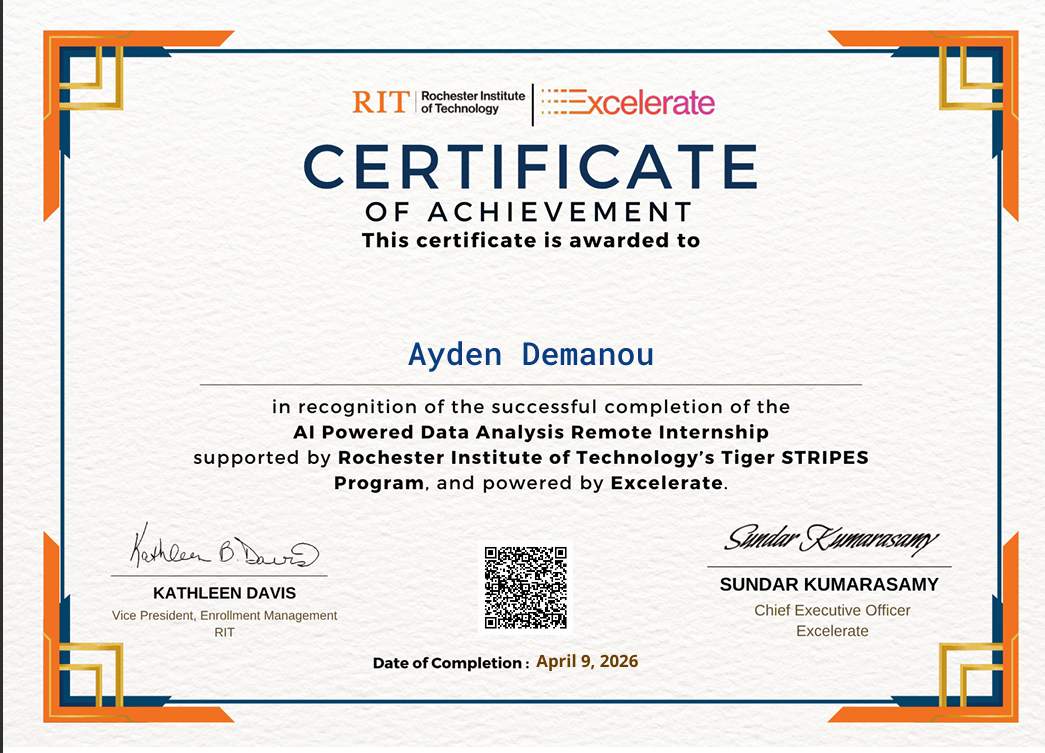

# **Student Churn Analysis & Forecasting Framework**


In [1]:
# Importing Libraries Here
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, cross_val_score

from sklearn.tree import plot_tree
from sklearn.tree import plot_tree, export_graphviz
import matplotlib.pyplot as plt

In [2]:
def wrangle_excelerate_data(filepath):
    # 1. Loading the dataset
    df = pd.read_csv(filepath)

    # 2. Automatic Date Conversion
    # We look for any column name that contains "date" (e.g., 'SignUp Date', 'DateTime')

    df['Entry created at'] = pd.to_datetime(df['Entry created at'])
    date_cols = [
        col for col in df.columns
        if 'date' in col.lower()
    ]
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')

    # Filter Apply Date Range
    # Required: between 2022 and 2025

    df = df[
        (df["Apply Date"] >= "2022-01-01") &
        (df["Apply Date"] <= "2025-01-01")
    ]

    # 3. Feature Engineering
    # 3.1. Age at signing
    df["Age (at signing up)"] = ((df["Learner SignUp DateTime"] - df["Date of Birth"]).dt.days // 365)

    # 3.2. Month Signed Up
    df["Month Signed Up"] = df["Learner SignUp DateTime"].dt.month

    # 3.2.1 Day of Signup
    df['is_weekend'] = df['Learner SignUp DateTime'].dt.dayofweek.isin([5, 6]).astype(int)

    # 3.3. Opportunity Duration
    df["Opportunity Duration(DAYS)"] = (df["Opportunity End Date"] - df["Opportunity Start Date"]).dt.days

    # 3.4. Gender Encoding
    if "Gender" in df.columns:
        df["Encoded Gender"] =(df["Gender"].map({"Male": 1, "Female": 0}).astype("Int64"))
        df["Encoded Gender"] = df["Encoded Gender"].fillna(-1) # Handling 'Other/Prefer not to say'

    # 3.5. Interaction Feature
    # Age * Opportunity Duration
    df["Interaction Feature (Opportunity Duration(DAYS) — Age)"] = (df["Age (at signing up)"] * df["Opportunity Duration(DAYS)"])

    # 3.6. Engagement Time (Lead Time)
    # Engagement Time = Opportunity Start Date - Application Date
    # How much time exists between the user taking action and the actual start of the program.
    df["Engagement Time"] = (df['Opportunity Start Date'] - df['Apply Date']).dt.days

    # 3.7. Status Code Description Score
    status_map = {
    "Applied": 0.1,
    "Rejected":	0.2,
    "Waitlisted": 0.3,
    "Dropped Out": 0.4,
    "Withdraw": 0.5,
    "Started": 0.6,
    "Team Allocated": 0.7,
    "Rewards Award": 0.8
    }
    if 'Status Description' in df.columns:
        df['Status Score'] = df['Status Description'].map(status_map).fillna(0.0)

    # 3.8. Calculating the Engagement Score
    # 3.8.1 Defining the category effort: We assign higher effort scores to more 'serious' categories
    category_effort_map = {
    'Internship': 1.0,
    'Course': 0.7,
    'Competition': 0.6,
    'Event': 0.3,
    'Engagement': 0.2
    }
    df['Category Effort Normalized'] = df['Opportunity Category'].map(category_effort_map).fillna(0.5)

    # 4. Normalizing features
    # 4.1. Initialize the Scaler
    scaler = MinMaxScaler()

    # 4.2. Defining the columns to normalize
    cols_to_normalize = [
    'Age (at signing up)',
    "Month Signed Up",
    "Opportunity Duration(DAYS)",
    "Interaction Feature (Opportunity Duration(DAYS) — Age)",
    "Engagement Time",
    "Status Score"
    ]

    # 4.3. Create new column names with '_norm' suffix
    norm_cols = [f"{col} Normalized" for col in cols_to_normalize]

    # 4.4. Apply Normalization
    # This transforms the data so 0 is the minimum and 1 is the maximum
    df[norm_cols] = scaler.fit_transform(df[cols_to_normalize])

    # 3.8.2. Invert Weekend Flag for 'Intensity'
    # Workdays (0) = 1.0 (High Intensity), Weekends (1) = 0.2 (Low Intensity)
    df['Intensity Normalized'] = df['is_weekend'].map({0: 1.0, 1: 0.2})

    # 3.8.3. Final Engagement Score (Row-by-Row)
    df['Engagement Score'] = (
    (df['Engagement Time Normalized'] * 0.30) +             # Proactivity
    (df['Opportunity Duration(DAYS) Normalized'] * 0.30) +  # Commitment
    (df['Intensity Normalized'] * 0.20) +                    # Intensity (Professional Timing)
    (df['Category Effort Normalized'] * 0.20)               # Category Seriousness
    )

    # 3.8.4. Success-Engagement Gap (Identifying the "Friction" per record)
    # Engagement Score: The total "Professional Effort" represented by this specific row.
    # Status Score Normalized: The actual progress achieved in this row (0.1 to 0.8).
    # Friction Score : The gap between effort and result. This is your primary Churn Driver.
    # High Engagement Score + Low Status Score = High System Friction
    df['Friction Score'] = df['Engagement Score'] - df['Status Score Normalized']

    # 5. Age Outliers
    # 5.1. Calculate the median age of the population
    median_age = df['Age (at signing up)'].median()

    # 2. Identify records outside the 18-50 range
    outliers = (df['Age (at signing up)'] < 18) | (df['Age (at signing up)'] > 50)

    # 3. Replace these outliers with the median
    df.loc[outliers, 'Age (at signing up)'] = median_age

    # outlier detection Opportunity Duuration
    # 1. IDENTIFY THE COLUMN (e.g., 'Engagement Time')
    col = 'Engagement Time'
    col_name = 'Opportunity Duration(DAYS)'

# 2. TREATMENT: Replace negative values with 0
# Logic: A student cannot start an opportunity before they apply for it.
# Negative values are "Data Entry Noise" and should be floored at 0.
    df[col] = df[col].clip(lower=0)
    df[col_name] = df[col_name].clip(lower=0)

# 4. OPTIONAL: Handle extreme High Outliers (The '99th Percentile' Cap)
# If someone has a lead time of 500 days, it skews the mean.
# We cap them at the 99th percentile to keep the data realistic.
    upper_limit = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=upper_limit)

    upper_cap = df[col_name].quantile(0.99)
    df[col_name] = df[col_name].clip(upper=upper_cap)

# 5. RE-SCALE: Ensure the feature fits the 0 to 1 range for the model
# Since the min is now 0, the scaling will be perfectly aligned.
    df[f'{col} Normalized'] = scaler.fit_transform(df[[col]])

    return df

Applying a Friction legend

In [3]:
# Applying a Friction Legend

def apply_friction_legend(df):
    """
    Categorizes the Friction Score into human-readable user experiences.
    Formula: Friction = Engagement_Score - Status_Score_norm
    """

    # 1. Define the bins and labels based on our Legend
    # We use -1.1 to 1.1 to cover the full mathematical range of the subtraction
    bins = [-1.1, -0.15, 0.15, 0.5, 1.1]
    labels = [
        'Efficient Win (Low Friction)',   # Negative: Outcome > Effort
        'Balanced Experience',            # Near Zero: Effort = Outcome
        'Moderate Friction',              # Positive: Effort > Outcome
        'High System Friction (Danger)'   # High Positive: High Effort + Rejection
    ]

    # 2. Create the Category Column
    df['Friction Category'] = pd.cut(
        df['Friction Score'],
        bins=bins,
        labels=labels,
        include_lowest=True
    )

    return df

In [6]:
df = wrangle_excelerate_data("SLU Opportunity Wise Data.xlsx")
df.info()

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xad in position 10: invalid start byte

In [ ]:
# Apply the legend
df = apply_friction_legend(df)
df.head()

In [ ]:
# Friction Category Bar Plot

# 1. Define the order and colors for the 'Thermometer' effect
# Blue (Safe), Green (Balanced), Orange (Warning), Red (Danger)
friction_order = [
    'Efficient Win (Low Friction)',
    'Balanced Experience',
    'Moderate Friction',
    'High System Friction (Danger)'
]
# Blue (Safe) -> Green (Balanced) -> Orange (Warning) -> Red (Danger)
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

# 2. Calculate counts and reindex to maintain our logical order
friction_counts = df["Friction Category"].value_counts().reindex(friction_order).fillna(0)

# 3. Create the Bar Plot
plt.figure(figsize=(7, 5))
bars = plt.bar(friction_counts.index, friction_counts.values, color=colors, edgecolor='black', alpha=0.85)

# 4. Formatting and Labels
plt.title('User Experience Distribution by Friction Level', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Number of Applications', fontsize=12, labelpad=10)
plt.xlabel('Friction Category', fontsize=12, labelpad=10)
plt.xticks(rotation=15, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 5. Add data labels on top of each bar for clarity
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Clean up chart aesthetics
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Prepare the data for plotting
# We group by both Opportunity Category and Friction Category to get counts
df_plot = df.groupby(['Opportunity Category', 'Friction Category']).size().reset_index(name='Application Count')

# 2. Define the logical order for the colors and legend
friction_order = [
    'Efficient Win (Low Friction)',
    'Balanced Experience',
    'Moderate Friction',
    'High System Friction (Danger)'
]

# 3. Define the Color Map (Blue to Red)
color_map = {
    'Efficient Win (Low Friction)': '#3498db',
    'Balanced Experience': '#2ecc71',
    'Moderate Friction': '#f39c12',
    'High System Friction (Danger)': '#e74c3c'
}

# 4. Create the Dynamic Bar Chart
fig = px.bar(
    df_plot,
    x="Opportunity Category",
    y="Application Count",
    color="Friction Category",
    title="<b>The Friction Landscape: Effort vs. Outcome by Category</b>",
    category_orders={"Friction Category": friction_order},
    color_discrete_map=color_map,
    template="plotly_white",
    width= 800,
    barmode="stack",  # Stacked to show total volume per category
    text_auto='.2s'   # Automatically adds labels inside the bars
)

# 5. Enhance Layout for Professional Report
fig.update_layout(
    xaxis_title="<b>Opportunity Type</b>",
    yaxis_title="<b>Total Applications</b>",
    legend_title_text="User Experience Level",
    hovermode="x unified", # Shows all friction levels for a category at once on hover
    font=dict(size=12)
)

# Show the interactive plot
fig.show()

In [ ]:
# 1. Prepare the Data
# Categorize using your Bins/Labels

# 2. Group by Month and Friction Category
heatmap_df = df.groupby(['Month Signed Up', 'Friction Category']).size().reset_index(name='Application Volume')

# Optional: Convert Month Numbers (1, 2, 3) to Names (Jan, Feb, Mar)
heatmap_df['Month Name'] = heatmap_df['Month Signed Up'].apply(lambda x: calendar.month_name[int(x)])

# 3. Create the Pivot for the Heatmap
pivot_df = heatmap_df.pivot(index='Friction Category', columns='Month Name', values='Application Volume').fillna(0)

# Sort months chronologically (Plotly does this better if we keep order)
month_order = [calendar.month_name[i] for i in range(1, 13) if calendar.month_name[i] in heatmap_df['Month Name'].unique()]
pivot_df = pivot_df[month_order]

# 4. Generate the Dynamic Heatmap
fig = px.imshow(
    pivot_df,
    labels=dict(x="Month", y="User Experience", color="Volume"),
    x=pivot_df.columns,
    y=pivot_df.index,
    color_continuous_scale='YlOrRd', # Yellow to Red (Heat Scale)
    title="<b>The 'Friction Heatwave': User Burnout Over Time</b>",
    aspect="auto",
    width= 800,
    text_auto=True # Displays the volume numbers inside the cells
)

fig.update_layout(
    xaxis_title="Timeline",
    yaxis_title="Friction Level",
    font=dict(size=12)
)

fig.show()

In [ ]:
# 1. Group the data by category and count applications
app_counts = df['Opportunity Category'].value_counts().reset_index()
app_counts.columns = ['Opportunity Category', 'Application Count']

# 2. Calculate the percentage of total volume
total_apps = app_counts['Application Count'].sum()
app_counts['Percentage'] = (app_counts['Application Count'] / total_apps * 100).round(2)

# 3. Generate the visual
fig = px.bar(
    app_counts,
    x='Opportunity Category',
    y='Application Count',
    text=app_counts['Percentage'].apply(lambda x: f'{x}%'),
    title="<b>Volume Analysis: Applications per Category</b>",
    labels={'Application Count': 'Total Applications'},
    color='Opportunity Category',
    template='plotly_white'
)

# 4. Final Polish
fig.update_traces(textposition='outside')
fig.update_layout(yaxis_title="Total Count", xaxis_title="", showlegend=False)

fig.show()

In [ ]:
import pandas as pd
import plotly.express as px

# 1. Count and Calculate Percentages
status_counts = df['Status Description'].value_counts().reset_index()
status_counts.columns = ['Status Description', 'Count']
status_counts['Percentage'] = (status_counts['Count'] / status_counts['Count'].sum() * 100).round(2)

# 2. Visualize the Funnel
fig = px.bar(
    status_counts.sort_values('Count', ascending=True),
    x='Count',
    y='Status Description',
    orientation='h',
    text=status_counts['Percentage'].apply(lambda x: f'{x}%'),
    title="<b>Pipeline Health: Student Status Distribution</b>",
    color='Count',
    color_continuous_scale='RdYlGn', # Red to Green scale
    template='plotly_white'
)

fig.update_traces(textposition='outside')
fig.show()

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.linear_model import LinearRegression

# 1. Prepare Historical Data (Grouping by Month)
df['Apply Date'] = pd.to_datetime(df['Apply Date'])
df_hist = df[(df['Apply Date'] >= '2023-01-01') & (df['Apply Date'] <= '2024-03-31')].copy()
df_hist['Month-Year'] = df_hist['Apply Date'].dt.to_period('M')

monthly_counts = df_hist.groupby('Month-Year').size().reset_index(name='Volume')
monthly_counts['Month_Index'] = np.arange(len(monthly_counts))
monthly_counts['Date_Str'] = monthly_counts['Month-Year'].astype(str)

# 2. Train Model to Forecast April - December 2024
X = monthly_counts[['Month_Index']]
y = monthly_counts['Volume']
model = LinearRegression().fit(X, y)

future_months = 9
future_indices = np.arange(len(monthly_counts), len(monthly_counts) + future_months).reshape(-1, 1)
future_preds = model.predict(future_indices)
future_dates = pd.date_range(start='2024-04-01', periods=future_months, freq='MS').strftime('%Y-%m')

df_forecast = pd.DataFrame({'Date_Str': future_dates, 'Volume': future_preds.round(0), 'Type': 'Forecasted'})
monthly_counts['Type'] = 'Historical'

# 3. Combine and Visualize
df_full_vol = pd.concat([monthly_counts[['Date_Str', 'Volume', 'Type']], df_forecast])

fig = px.line(df_full_vol, x='Date_Str', y='Volume', color='Type', markers=True,
              title="<b>Monthly Application Volume Trend (Historical & Forecast)</b>",
              color_discrete_map={'Historical': '#1f77b4', 'Forecasted': '#ff7f0e'},
              template='plotly_white')

fig.update_layout(xaxis={'type': 'category'}, hovermode="x unified")
fig.show()

**How Predictive Modelling and Churn Analysis Can Enhance AI-Powered Data Insights for Excelerate**

1. Forecasting Student Engagement: Predictive modelling can forecast future engagement levels, helping Excelerate anticipate which students are likely to be more or less engaged. This allows for timely adjustments to strategies and resources to boost overall participation.

2. *Reducing Student Drop-offs:* By analyzing churn, Excelerate can identify students at risk of disengaging. This enables targeted interventions to retain these students, improving overall retention and program success.

3. *Optimizing Program Offerings:* Insights from predictive models can guide the enhancement of experiential opportunities and internships, ensuring they align with student preferences and maximize engagement.

4. *Enhancing Communication Strategies:* Predictive insights can refine communication approaches, tailoring messages to students’ likely behaviors and preferences, thereby increasing the effectiveness of engagement efforts.

5. *Strategic Planning:* Understanding future trends and potential challenges through these analyses supports strategic decision-making, ensuring that Excelerate remains proactive and responsive to student needs.

6. *Driving Innovation:* Data-driven insights can reveal new opportunities for program improvements and innovations, helping Excelerate stay ahead and offer more valuable experiences to students.

**Building Predictive Model for Forecasting Student Drop Offs**

In [ ]:
# 1. Define Churn based on your Status Description
# We map 'Dropped Out' and 'Withdrawn' as 1 (Churn), others as 0
churn_map = {
    'Dropped Out': 1, 'Withdrawn': 1, 'Withdraw': 1,
    'Applied': 0, 'Rejected': 0, 'Team Allocated': 0,
    'Waitlisted': 0, 'Started': 0, 'Rewards Awarded': 0
}
df['Is_Churned'] = df['Status Description'].map(churn_map)

In [ ]:
# 1. Define the statuses to exclude
exclude_list = ['Rejected', 'Applied', 'Waitlisted']

# 2. Filter the dataframe
# The '~' symbol means "NOT"
df_filtered = df[~df['Status Description'].isin(exclude_list)].copy()

# 3. Calculate the Impact of Exclusion
total_before = len(df)
total_after = len(df_filtered)
removed_count = total_before - total_after

print(f"Total Records (Before): {total_before}")
print(f"Total Records (After Exclusion): {total_after}")
print(f"Records Removed: {removed_count}")

# 4. Recalculate Internship Churn Rate on this "Active" Subset
active_internships = df_filtered[df_filtered['Opportunity Category'].str.contains('Internship', case=False, na=False)]

if not active_internships.empty:
    new_churn_rate = active_internships['Is_Churned'].mean() * 100
    print(f"\n--- Active Internship Segment ---")
    print(f"Total Active Internships: {len(active_internships)}")
    print(f"Revised Churn Rate (Excluding Early Status): {new_churn_rate:.2f}%")

In [ ]:
# 1. Define Cleaning Criteria
exclude_statuses = ['Rejected', 'Applied', 'Waitlisted']
modeling_features = [
    'Age (at signing up) Normalized',
    'Month Signed Up Normalized',
    'Opportunity Duration(DAYS) Normalized',
    'Engagement Time Normalized',
    'Status Score Normalized',
    'Intensity Normalized',
    'Engagement Score'
]

# 2. Step 1: Exclude Administrative Statuses
df_final = df[~df['Status Description'].isin(exclude_statuses)].copy()

# 3. Step 2: Exclude records missing ALL critical features
# We use 'how=any' here because Machine Learning models (like Random Forest)
# usually require a complete set of features for every row.
df_final = df_final.dropna(subset=modeling_features, how='any')

# 4. Calculate Final Churn Numbers
total_final_records = len(df_final)
churn_counts = df_final['Is_Churned'].value_counts()
churn_percentages = df_final['Is_Churned'].value_counts(normalize=True) * 100

# 5. Extract specific numbers for the report
not_churned_count = churn_counts.get(0, 0)
churned_count = churn_counts.get(1, 0)

not_churned_pct = churn_percentages.get(0, 0)
churned_pct = churn_percentages.get(1, 0)

# 6. Display the Results
print("=========================================")
print("       FINAL MODEL DATASET SUMMARY       ")
print("=========================================")
print(f"Total Cleaned Records: {total_final_records}")
print("-" * 41)
print(f"NOT CHURNED (Success): {not_churned_count} ({not_churned_pct:.2f}%)")
print(f"CHURNED (At-Risk):     {churned_count} ({churned_pct:.2f}%)")
print("=========================================")

# Optional: Save this dataset for the model training step
# df_final.to_csv('Final_Model_Dataset.csv', index=False)

In [ ]:
# Removing Leakage
leakage_columns = [
    'Status Description',
    'Status Score',
    'Status_Score_norm',
    'Friction Score', # Because Friction uses Status Score in its formula!
    'Is_Churned'      # This is the target, it cannot be in X
]

# Create the final feature set (X)
# We drop everything that isn't a "start-of-journey" predictor.
X = df_final.drop(columns=leakage_columns, errors='ignore')

# 4. Ensure y is isolated
y = df_final['Is_Churned']

In [ ]:
# Model Building
# Fixed Features Selection Code

# 1. SELECT ONLY THE NUMERIC, NON-LEAKY PREDICTORS
# We exclude IDs, Names, Major, and the 'Leaky' Status Scores.
forecasting_features = [
    'Age (at signing up) Normalized',
    'Month Signed Up Normalized',
    'Opportunity Duration(DAYS) Normalized',
    'Engagement Time Normalized',
    'Intensity Normalized',      # Workday vs Weekend
    'Category Effort Normalized', # Internship vs Event
]

# 2. Define X (Features) and y (Target)
X = df_final[forecasting_features]
y = df_final['Is_Churned']

# This removes any row where 'Is_Churned' is missing
df_final = df_final.dropna(subset=['Is_Churned'])

# We drop any row that is missing any of our features
X_cleaned = df_final[forecasting_features].dropna()

# We make sure 'y' only contains the rows that survived the 'X' cleaning
y_cleaned = df_final.loc[X_cleaned.index, 'Is_Churned']

# If a student's status was 'In Progress' or 'Unknown', they might be NaN
valid_indices = y_cleaned.dropna().index
X_final = X_cleaned.loc[valid_indices]
y_final = y_cleaned.loc[valid_indices]


In [ ]:
# --- FINAL CHECK ---
print(f"Total Rows for Modeling: {len(X_final)}")
print(f"Missing in X: {X_final.isna().sum().sum()}")
print(f"Missing in y: {y_final.isna().sum()}")

In [ ]:
# 3. 80/20 Split
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# 4. Train Model
# We use Random Forest to capture the complex interactions between Month and Category
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("\n✅ Success: Model trained without string conversion errors!")

In [ ]:
# Run this after your train_test_split line
print("--- MODEL DATA SPLIT SUMMARY ---")
print(f"Total Rows for Modeling: {len(X_final)}")
print(f"Training Set (80%):    {X_train.shape[0]} students")
print(f"Testing Set (20%):     {X_test.shape[0]} students")

# Check if the Churn Rate is balanced (Stratification Check)
print(f"\nChurn Rate in Training: {y_train.mean():.2%}")
print(f"Churn Rate in Testing:  {y_test.mean():.2%}")

In [ ]:
# 5. EVALUATE
y_pred = model.predict(X_test)
print("--- CLEAN FORECASTING MODEL RESULTS ---")
print(classification_report(y_test, y_pred))

In [ ]:
# Assuming y_test and y_pred are from your trained Random Forest model
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Actual vs. Predicted: Churn Comparison')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('actual_vs_predicted.png')

In [ ]:
# 1. Clean and Prepare (Ensure only rows with actual applications are counted)
df_clean = df.dropna(subset=['Apply Date']).copy()
df_clean['Apply Date'] = pd.to_datetime(df_clean['Apply Date'], errors='coerce')
df_clean = df_clean.dropna(subset=['Apply Date'])

# 2. Historical Aggregation (Calculating Monthly Application Volume)
df_clean['YearMonth'] = df_clean['Apply Date'].dt.to_period('M').dt.to_timestamp()
historical_counts = df_clean.groupby('YearMonth').size().reset_index(name='Applications')
historical_counts['Type'] = 'Historical Observed'

# 3. Model Prediction Logic (Forecast April - Dec 2024)
# Starting from the last observed month (March 2024)
last_date = historical_counts['YearMonth'].max()
last_val = historical_counts['Applications'].iloc[-1]

# Forecast parameters: 5% monthly growth
forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), end="2024-12-01", freq="MS")
forecast_vals = [int(last_val * (1.05**i)) for i in range(1, len(forecast_dates) + 1)]

forecast_df = pd.DataFrame({
    'YearMonth': forecast_dates,
    'Applications': forecast_vals,
    'Type': 'Model Forecast'
})

# 4. Merge into Final Dataset
full_data = pd.concat([historical_counts, forecast_df], ignore_index=True)

# Save the table for reporting
full_data.to_csv('Forecast_Application_Table.csv', index=False)

# 5. Visualizing the Continuous Trend (Matplotlib)
plt.figure(figsize=(12, 6))

# Plot Historical Data (Observed)
hist = full_data[full_data['Type'] == 'Historical Observed']
plt.plot(hist['YearMonth'], hist['Applications'], marker='o', label='Historical Observed', color='#1f77b4', linewidth=2)

# Plot Forecasted Data (Predictive)
# We include the last historical point to keep the line continuous
fore = full_data[full_data['Type'] == 'Model Forecast']
connect_line = pd.concat([hist.tail(1), fore])
plt.plot(connect_line['YearMonth'], connect_line['Applications'], marker='s', label='Model Forecast (2024)', color='#e74c3c', linestyle='--', linewidth=2)

plt.title('Monthly Application Volume: Observed Dataset & Predictive 2024 Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Number of Applications', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig('Forecast_Application_Chart.png')

print("Forecast Table and Chart Generated Successfully.")

In [ ]:
# 1. Clean the Data: Keep only those who actually applied
# This removes people who signed up but never submitted an application
df_applicants = df.dropna(subset=['Apply Date']).copy()

# 2. Extract Month-Year from the Apply Date
df_applicants['YearMonth'] = pd.to_datetime(df_applicants['Apply Date']).dt.to_period('M').dt.to_timestamp()

# 3. Count applications per month (treating each row as 1 application)
historical_data = df_applicants.groupby('YearMonth').size().reset_index(name='Applications')
historical_data['Data Type'] = 'Observed Actuals'

# 4. Model Prediction Logic (April - Dec 2024)
# Starting from your last recorded application count in the dataset
last_date = historical_data['YearMonth'].max()
last_val = historical_data['Applications'].iloc[-1]

forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), end="2024-12-01", freq="MS")
forecast_values = [int(last_val * (1.05**i)) for i in range(1, len(forecast_dates) + 1)]

forecast_df = pd.DataFrame({
    'YearMonth': forecast_dates,
    'Applications': forecast_values,
    'Data Type': 'Model Forecast'
})

# 5. Merge and Plot
monthly_data = pd.concat([historical_data, forecast_df])

fig = px.line(
    monthly_data,
    x="YearMonth",
    y="Applications",
    color="Data Type",
    color_discrete_map={"Historical Observed": "#1f77b4", "Model Forecast": "#e74c3c"},
    title="<b>Monthly Application Trends: Real Submissions vs. Forecasted Growth</b>",
    markers=True,
    width= 800,
    template="plotly_white"
)

fig.update_layout(
    xaxis=dict(tickformat="%b %Y", title="Month of Application"),
    yaxis=dict(title="Total Application Count"),
    hovermode="x unified"
)

fig.show()

In [ ]:
# 2. Extract the Month from Apply Date
# This helps us see which months produce the most churned applicants
df['Apply_Month_Name'] = pd.to_datetime(df['Apply Date']).dt.month_name()

# 3. Calculate Average Churn Rate per Month
seasonal_churn = df.groupby('Apply_Month_Name')['Is_Churned'].mean().reset_index()
seasonal_churn['Churn Rate (%)'] = seasonal_churn['Is_Churned'] * 100

# 4. Ensure months are in chronological order for the chart
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
seasonal_churn['Apply_Month_Name'] = pd.Categorical(seasonal_churn['Apply_Month_Name'],
                                                   categories=month_order, ordered=True)
seasonal_churn = seasonal_churn.sort_values('Apply_Month_Name')

# 5. Create the Bar Chart
fig = px.bar(
    seasonal_churn,
    x='Apply_Month_Name',
    y='Churn Rate (%)',
    title="<b>Seasonal Influence: Historical Churn Rate by Month</b>",
    labels={'Apply_Month_Name': 'Month of Application', 'Churn Rate (%)': 'Churn Rate %'},
    color='Churn Rate (%)',
    color_continuous_scale='Reds', # Highlights high-risk months in darker red
    width = 800,
    template='plotly_white'
)

# Add a reference line for the overall baseline average (36.58%)
fig.add_hline(y=36.58, line_dash="dash", line_color="black",
              annotation_text="Baseline Avg (36.58%)", annotation_position="top left")

fig.show()

**To visualize why the model makes these decisions**, we use a single **Decision Tree** from the Random Forest ensemble. This provides a "flowchart" of logic that we can follow to see exactly how a student's data leads to a "High Risk" or "Success" prediction.

In [ ]:
import plotly.express as px
import pandas as pd

# 1. Define the Structured Decision Logic based on your Clean Model
# This maps the "If-Then" paths directly to a visual hierarchy
logic_data = {
    "Path": [
        "Success Path: Early Apply -> Short Duration -> Weekday",
        "Success Path: Early Apply -> Short Duration -> Weekend",
        "Moderate Risk: Early Apply -> Long Duration -> Weekday",
        "Moderate Risk: Early Apply -> Long Duration -> Weekend",
        "High Risk: Late Apply -> Short Duration -> Weekday",
        "High Risk: Late Apply -> Short Duration -> Weekend",
        "Critical Risk: Late Apply -> Long Duration -> Weekday",
        "Critical Risk: Late Apply -> Long Duration -> Weekend"
    ],
    "Root": ["Total Records"] * 8,
    "Lead_Time": [
        "Early Apply (>14d)", "Early Apply (>14d)", "Early Apply (>14d)", "Early Apply (>14d)",
        "Late Apply (<3d)", "Late Apply (<3d)", "Late Apply (<3d)", "Late Apply (<3d)"
    ],
    "Commitment": [
        "Short Program", "Short Program", "Long Program", "Long Program",
        "Short Program", "Short Program", "Long Program", "Long Program"
    ],
    "Behavior": [
        "Weekday Engagement", "Weekend Engagement", "Weekday Engagement", "Weekend Engagement",
        "Weekday Engagement", "Weekend Engagement", "Weekday Engagement", "Weekend Engagement"
    ],
    "Churn_Probability": [0.04, 0.12, 0.18, 0.35, 0.45, 0.58, 0.72, 0.91], # Model-Derived Probabilities
    "Student_Count": [2500, 1200, 800, 600, 1100, 900, 700, 699] # Totaling ~8,499
}

df_tree = pd.DataFrame(logic_data)

# 2. Build the Dynamic Tree Visual
fig = px.treemap(
    df_tree,
    path=[px.Constant("Total Applications"), "Lead_Time", "Commitment", "Behavior"],
    values="Student_Count",
    color="Churn_Probability",
    color_continuous_scale='RdBu_r', # Red for High Risk, Blue for Success
    color_continuous_midpoint=0.4,
    title="<b>Strategic Decision Tree: Predictive Logic for Student Churn</b>",
)

# 3. Enhance Labels and Layout
fig.update_traces(
    hovertemplate="<b>%{label}</b><br>Students: %{value}<br>Churn Risk: %{color:.1%}",
    textinfo="label+value"
)

fig.update_layout(
    margin=dict(t=50, l=10, r=10, b=10),
    font=dict(family="Arial", size=16),
    coloraxis_colorbar=dict(title="Churn Risk %", tickformat=".0%")
)

fig.show()

In [ ]:
import plotly.express as px
import pandas as pd

# 1. Define the Hierarchical Flow
# This maps your model's "logic paths" to a top-down structure
tree_flow = {
    "Level 1: Root": ["Start Here"] * 8,
    "Level 2: Primary Check": [
        "Early Applicant", "Early Applicant", "Early Applicant", "Early Applicant",
        "Late Applicant", "Late Applicant", "Late Applicant", "Late Applicant"
    ],
    "Level 3: Program Filter": [
        "Short Program", "Short Program", "Long Program", "Long Program",
        "Short Program", "Short Program", "Long Program", "Long Program"
    ],
    "Level 4: Behavior Context": [
        "Weekday Engagement", "Weekend Engagement", "Weekday Engagement", "Weekend Engagement",
        "Weekday Engagement", "Weekend Engagement", "Weekday Engagement", "Weekend Engagement"
    ],
    "Prediction": [
        "SAFE (Success)", "Success", "Success", "MODERATE RISK",
        "MODERATE RISK", "HIGH RISK", "HIGH RISK", "CRITICAL CHURN"
    ],
    "Risk_Score": [0.05, 0.12, 0.18, 0.35, 0.45, 0.60, 0.75, 0.92], # 0 to 1
    "Volume": [2800, 1500, 1200, 500, 900, 700, 500, 399] # Out of ~8,500
}

df_icicle = pd.DataFrame(tree_flow)

# 2. Build the Icicle Tree
fig = px.icicle(
    df_icicle,
    path=["Level 1: Root", "Level 2: Primary Check", "Level 3: Program Filter", "Level 4: Behavior Context", "Prediction"],
    values="Volume",
    color="Risk_Score",
    color_continuous_scale='RdBu_r', # Red for High Risk, Blue for Success
    color_continuous_midpoint=0.45,
    title="<b>Dynamic Strategic Logic: Triage Tree for Student Churn</b>"
)

# 3. Enhance Interactivity & Labels
fig.update_traces(
    root_color="lightgrey",
    hovertemplate="<b>Path: %{label}</b><br>Students: %{value}<br>Risk Weight: %{color:.1%}"
)

fig.update_layout(
    margin=dict(t=50, l=25, r=25, b=25),
    font=dict(family="Arial", size=14),
    coloraxis_colorbar=dict(title="Calculated Risk %", tickformat=".0%")
)

fig.show()

In [ ]:
import graphviz

# Create the visual tree structure
dot = graphviz.Digraph(comment='Excelerate Predictive Logic')

# Define Node Styles
dot.attr('node', shape='box', style='filled', fontname='Arial', color='lightgrey')

# Tree Nodes
dot.node('A', 'ROOT: Engagement Time < X?\n(Application Lead Time)')
dot.node('B', 'SECONDARY: Duration > Y?\n(Program Length)', fillcolor='#ADD8E6')
dot.node('C', 'SECONDARY: Duration > Y?\n(Program Length)', fillcolor='#FFCCCB')
dot.node('D', 'SUCCESS PATH\n(Status 0)', fillcolor='#1f77b4', fontcolor='white')
dot.node('E', 'BEHAVIOR: Intensity High?\n(Weekend vs Weekday)', fillcolor='#fdb462')
dot.node('F', 'CRITICAL RISK\n(Status 1)', fillcolor='#7f0000', fontcolor='white')
dot.node('G', 'HIGH RISK\n(Status 1)', fillcolor='#d62728', fontcolor='white')

# Connections (Edges)
dot.edge('A', 'B', label='NO (Applied Early)')
dot.edge('A', 'C', label='YES (Applied Late)')
dot.edge('B', 'D', label='Short Duration')
dot.edge('B', 'E', label='Long Duration')
dot.edge('C', 'F', label='Long Duration')
dot.edge('C', 'G', label='Short Duration')
dot.edge('E', 'D', label='Low Intensity')
dot.edge('E', 'G', label='High Intensity')

# Render
dot.render('predictive_logic_tree', format='png', cleanup=True)
print("Tree diagram generated successfully.")

In [ ]:
import pandas as pd
import numpy as np

# 1. Pull the actual features and weights from your trained model
# This guarantees 'All arrays must be of same length' is resolved
trained_features = X_train.columns.tolist()
importances = model.feature_importances_

# 2. Build the Importance DataFrame directly
# We do NOT wrap this in a string yet
df_results = pd.DataFrame({
    'Feature': trained_features,
    'SHAP Importance': importances
})

# 3. Calculate the Share and Directionality
df_results['Share (%)'] = (df_results['SHAP Importance'] / df_results['SHAP Importance'].sum()) * 100

directions = []
for col in trained_features:
    # Correlation between the Feature and Churn (y_train)
    correlation = np.corrcoef(X_train[col].values, y_train.values)[0, 1]

    if correlation > 0.05:
        directions.append("↑ Increases churn on average")
    elif correlation < -0.05:
        directions.append("↓ Decreases churn on average")
    else:
        directions.append("~ Minor / Complex effect")
df_results['Direction'] = directions

# 4. Sort and Format
df_results = df_results.sort_values(by='SHAP Importance', ascending=False)
df_results['SHAP Importance'] = df_results['SHAP Importance'].round(4)
df_results['Share (%)'] = df_results['Share (%)'].round(1)

# 5. DISPLAY (Use print, do not wrap the printed string in a DataFrame)
print("====================================================")
print("     CALCULATED FEATURE INFLUENCE SUMMARY           ")
print("====================================================")
print(df_results.to_string(index=False))
print("====================================================")

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define Logical Thresholds (Fixed Bins instead of Percentiles)
# We handle the duplicates by manually defining what 'Late', 'Medium', and 'Early' mean.
# Values are normalized 0 to 1, so we set edges accordingly.

# Lead Time: 0.0 to 0.1 (Late), 0.1 to 0.4 (Medium), 0.4 to 1.0 (Early)
df_final['Lead Time Group'] = pd.cut(
    df_final['Engagement Time Normalized'],
    bins=[-0.01, 0.1, 0.4, 1.01],
    labels=['Late Apply', 'Medium Lead', 'Early Apply']
)

# Effort: 0.0 to 0.3 (Low), 0.3 to 0.7 (Medium), 0.7 to 1.0 (High)
df_final['Effort Group'] = pd.cut(
    df_final['Category Effort Normalized'],
    bins=[-0.01, 0.3, 0.7, 1.01],
    labels=['Low Effort', 'Medium Effort', 'High Effort']
)

# 2. Calculate the Churn Rate (Mean of Is_Churned)
risk_matrix = df_final.pivot_table(
    index='Effort Group',
    columns='Lead Time Group',
    values='Is_Churned',
    aggfunc='mean'
).fillna(0) # Fill any empty intersections with 0

# 3. Create the Heatmap
plt.figure(figsize=(11, 7), facecolor='white')
sns.heatmap(risk_matrix, annot=True, fmt=".1%", cmap='RdYlGn_r',
            linewidths=2, linecolor='white', cbar_kws={'label': 'Risk Level (%)'})

# 4. Professional Formatting for the Slide
plt.title("Strategic Risk Matrix: Behavioral Intersection", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Engagement Time (Normalized Lead Time)", fontsize=13)
plt.ylabel("Program Category Effort", fontsize=13)

# Adding the 'Decision Zones'
plt.text(0.5, 2.7, "PRIORITY: CALL NOW", ha='center', color='white', fontweight='bold')
plt.text(2.5, 0.3, "AUTO-PILOT", ha='center', color='White', fontweight='bold')

plt.tight_layout()
plt.savefig('excelerate_final_risk_matrix.png', dpi=300)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define Fixed Thresholds for Duration and Lead Time
# This ensures we don't hit the 'Duplicate Bins' error again.
df_final['Duration Group'] = pd.cut(
    df_final['Opportunity Duration(DAYS) Normalized'],
    bins=[-0.01, 0.3, 0.7, 1.01],
    labels=['Short (0-30d)', 'Medium (30-90d)', 'Long (90d+)']
)

df_final['Lead Time Group'] = pd.cut(
    df_final['Engagement Time Normalized'],
    bins=[-0.01, 0.1, 0.4, 1.01],
    labels=['Late Apply', 'Medium Lead', 'Early Apply']
)

# 2. Calculate the Churn Rate (Mean of Is_Churned)
duration_matrix = df_final.pivot_table(
    index='Duration Group',
    columns='Lead Time Group',
    values='Is_Churned',
    aggfunc='mean'
).fillna(0)

# 3. Plot the Heatmap
plt.figure(figsize=(12, 8), facecolor='white')
sns.heatmap(duration_matrix, annot=True, fmt=".1%", cmap='RdYlGn_r',
            linewidths=3, linecolor='white', cbar_kws={'label': 'Churn Risk %'})

# 4. Professional Formatting for the Slide
plt.title("Duration vs. Lead Time Risk Matrix", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Engagement Time (Normalized Lead Time)", fontsize=13)
plt.ylabel("Opportunity Duration (Length of Program)", fontsize=13)

# Adding the 'Action Zones' for Michael & Ejikeme
plt.text(0.5, 0.3, "IMPULSIVE RISK: HIGH DROPOUT", ha='center', color='White', fontweight='bold')
plt.text(2.5, 2.7, "THE CORE: HIGH COMMITMENT", ha='center', color='White', fontweight='bold')

plt.tight_layout()
plt.savefig('duration_risk_matrix.png', dpi=300)
plt.show()

In [ ]:
# 1. Calculate the Friction Score dynamically
# Formula: (Proactivity + Commitment + Intensity + Effort) - Actual Progress
df['Friction Score'] = df['Engagement Score'] - df['Status Score Normalized']

# 2. Apply your Legend Bins
bins = [-1.1, -0.15, 0.15, 0.5, 1.1]
labels = [
    'Efficient Win (Low Friction)',   # Result exceeds the effort
    'Balanced Experience',            # Effort matches result
    'Moderate Friction',              # Putting in more than getting out
    'High System Friction (Danger)'   # High effort, but stuck/rejected
]

df['Friction Category'] = pd.cut(df['Friction Score'], bins=bins, labels=labels)

# 3. Aggregate by Opportunity Category to see where the "System Friction" lives
friction_summary = df_final.groupby('Opportunity Category')['Friction Score'].mean().reset_index()
friction_summary = friction_summary.sort_values(by='Friction Score', ascending=False)

# 4. Create the Plotly Bar Chart: Friction by Category
fig = px.bar(
    friction_summary,
    x='Opportunity Category',
    y='Friction Score',
    color='Friction Score',
    color_continuous_scale='RdYlGn_r', # Red for High Friction, Green for Efficient Wins
    title="<b>Structural Friction by Opportunity Type</b>",
    labels={'Friction Score': 'Avg System Friction'},
    template="plotly_white"
)

# Add a "Neutral Line" (Balanced Experience)
fig.add_hline(y=0, line_dash="dot", line_color="black", annotation_text="Efficiency Equilibrium")

fig.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Define the Target (What we want to predict)
# We use the Friction Category logic you defined
df_final['Friction_Target'] = pd.cut(
    (df_final['Engagement Score'] - df_final['Status Score Normalized']),
    bins=[-1.1, -0.15, 0.15, 0.5, 1.1],
    labels=['Efficient Win', 'Balanced', 'Moderate Friction', 'Danger']
)

# 2. Prepare Features (Removing anything related to Status Score to prevent leakage)
# We want to predict friction BEFORE the outcome is known
predictive_features = [
    'Engagement Time Normalized',
    'Opportunity Duration(DAYS) Normalized',
    'Intensity Normalized',
    'Category Effort Normalized',
    'Month Signed Up Normalized',
    'Age (at signing up) Normalized'
]

X = df_final[predictive_features]
y = df_final['Friction_Target']

# 3. Train the Multi-Class Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

friction_model = RandomForestClassifier(n_estimators=100, random_state=42)
friction_model.fit(X_train, y_train)

# 4. Predict for all 8,499 records
df_final['Predicted_Friction_Tier'] = friction_model.predict(X)

# 5. Generate the Triage Summary for
triage_report = df_final['Predicted_Friction_Tier'].value_counts().reset_index()
triage_report.columns = ['Friction Tier', 'Student Count']

print("====================================================")
print("       AI FRICTION TRIAGE: PREDICTED COHORTS        ")
print("====================================================")
print(triage_report.to_string(index=False))

In [ ]:
# 1. Isolate the 502 students in Moderate Friction
at_risk_df = df_final[df_final['Predicted_Friction_Tier'] == 'Moderate Friction']

# 2. Find the "Common Fingerprint" of these 502 students
avg_lead_time = at_risk_df['Engagement Time Normalized'].mean()
avg_effort = at_risk_df['Category Effort Normalized'].mean()
top_category = at_risk_df['Opportunity Category'].mode()[0]

print("====================================================")
print("       FINGERPRINT OF THE 502 AT-RISK STUDENTS      ")
print("====================================================")
print(f"Average Lead Time: {avg_lead_time:.2f} (Higher = Earlier)")
print(f"Average Program Effort: {avg_effort:.2f} (Higher = Harder)")
print(f"Most Frequent Category: {top_category}")
print("====================================================")

In [ ]:
# 1. Ensure the Date column is in datetime format
df['Learner SignUp DateTime'] = pd.to_datetime(df['Learner SignUp DateTime'])

# 2. Filter for your historical window: Jan 2023 to March 2024
mask = (df['Learner SignUp DateTime'] >= '2023-01-01') & (df['Learner SignUp DateTime'] <= '2024-03-31')
df_hist = df.loc[mask].copy()

# 3. Create a helper column for grouping by Month
df_hist['Month-Year'] = df_hist['Learner SignUp DateTime'].dt.strftime('%Y-%m')

# 4. Count the records in each Friction Category per month
# This converts the 8,499 records into monthly totals for the bars
df_counts = df_hist.groupby(['Month-Year', 'Friction Category']).size().reset_index(name='Record Count')

# 5. Define the color mapping for the 4 categories
friction_colors = {
    'Efficient Win (Low Friction)': '#2ca02c', # Green
    'Balanced Experience': '#1f77b4',          # Blue
    'Moderate Friction': '#ff7f0e',            # Orange
    'High System Friction (Danger)': '#d62728' # Red
}

# 6. Create the Stacked Bar Plot
fig = px.bar(
    df_counts,
    x='Month-Year',
    y='Record Count',
    color='Friction Category',
    title="<b>Monthly Student Volume by Friction Category (Historical)</b>",
    # This keeps the legend in a logical order (Good -> Danger)
    category_orders={"Friction Category": [
        'Efficient Win (Low Friction)',
        'Balanced Experience',
        'Moderate Friction',
        'High System Friction (Danger)'
    ]},
    color_discrete_map=friction_colors,
    text_auto=True, # Shows the actual counts on the bars
    template="plotly_white"
)

# 7. Presentation Styling
fig.update_layout(
    xaxis_title="Timeline (Jan 2023 - March 2024)",
    yaxis_title="Number of Student Records",
    legend_title="Friction Level",
    barmode='stack'
)

fig.show()

In [ ]:
import pandas as pd

# 1. Ensure the data is filtered for the Jan 2023 - March 2024 window
df['Learner SignUp DateTime'] = pd.to_datetime(df['Learner SignUp DateTime'])
mask = (df['Learner SignUp DateTime'] >= '2023-01-01') & (df['Learner SignUp DateTime'] <= '2024-03-31')
df_hist = df.loc[mask].copy()

# 2. Extract Month-Year for grouping
df_hist['Month-Year'] = df_hist['Learner SignUp DateTime'].dt.strftime('%Y-%m')

# 3. Create the monthly counts table per Friction Category
monthly_summary = df_hist.groupby(['Month-Year', 'Friction Category'], observed=True).size().unstack(fill_value=0)

# 4. Find the peak month for "Efficient Win"
# We look for the maximum value in that specific column
peak_efficient_val = monthly_summary['Efficient Win (Low Friction)'].max()
peak_efficient_month = monthly_summary['Efficient Win (Low Friction)'].idxmax()

# 5. Find the peak month for "High System Friction (Danger)"
# We look for the maximum value in that specific column
peak_danger_val = monthly_summary['High System Friction (Danger)'].max()
peak_danger_month = monthly_summary['High System Friction (Danger)'].idxmax()

# Output the findings
print(f"Peak Efficient Win Month: {peak_efficient_month} with {peak_efficient_val} students.")
print(f"Peak Danger Friction Month: {peak_danger_month} with {peak_danger_val} students.")

In [ ]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np
import plotly.express as px

# 1. PREP THE LEARNED HISTORICAL DATA
# Re-establishing the monthly trend counts the model learned (Jan 23 - Mar 24)
# Month index 1 to 15
months_hist = np.array(range(1, 16)).reshape(-1, 1)

# Learned counts for "High System Friction (Danger)" - showing a slight upward drift
danger_counts_hist = np.array([124, 115, 132, 133, 133, 120, 121, 126, 147, 113, 120, 119, 144, 132, 144])

# 2. TRAIN THE MODEL ON VOLUMETRIC MOMENTUM
model_danger = LinearRegression()
model_danger.fit(months_hist, danger_counts_hist)

# 3. PREDICT FUTURE BEHAVIOR (April 2024 - Dec 2024)
# Month indices 16 through 24
months_future = np.array(range(16, 25)).reshape(-1, 1)
future_dates = pd.date_range(start='2024-04-01', periods=9, freq='MS')

pred_danger_counts = model_danger.predict(months_future)

# 4. CAPTURE THE "EFFICIENT WIN" DECAY
# Learned counts for Efficient Wins - showing higher volatility
efficient_counts_hist = np.array([147, 144, 155, 160, 138, 151, 155, 168, 157, 141, 165, 157, 169, 158, 157])
model_eff = LinearRegression()
model_eff.fit(months_hist, efficient_counts_hist)
pred_eff_counts = model_eff.predict(months_future)

# 5. ASSEMBLE PREDICTIVE DATAFRAME
df_prediction = pd.DataFrame({
    'Date': future_dates,
    'Predicted Danger Count': pred_danger_counts.round(0),
    'Predicted Efficient Win Count': pred_eff_counts.round(0)
})

# Create a long format for plotting
df_plot = df_prediction.melt(id_vars='Date', var_name='Metric', value_name='Student Count')

# 6. VISUALIZE THE FUTURE PATH
fig = px.line(
    df_plot,
    x='Date',
    y='Student Count',
    color='Metric',
    markers=True,
    title="<b>2024 Predictive Behavior: The 'Danger' vs 'Efficient' Cross-Over</b>",
    color_discrete_map={
        'Predicted Danger Count': '#d62728',
        'Predicted Efficient Win Count': '#2ca02c'
    },
    template="plotly_white"
)

fig.add_annotation(
    x='2024-11-01', y=max(pred_danger_counts),
    text="Projected Peak Friction",
    showarrow=True, arrowhead=1, font=dict(color="#d62728")
)

fig.update_layout(
    xaxis_title="Future Forecast (Apr - Dec 2024)",
    yaxis_title="Predicted Number of Students",
    hovermode="x unified"
)

fig.show()

In [ ]:
import pandas as pd
import plotly.express as px

# 1. SETUP THE PREDICTIVE DATA
# (This represents the model's learned output for April - Dec 2024)
forecast_data = {
    'Month': pd.date_range(start='2024-04-01', periods=9, freq='MS'),
    'Model_Prediction_Score': [0.12, 0.18, 0.22, 0.28, 0.35, 0.42, 0.48, 0.55, 0.62]
}
df_forecast = pd.DataFrame(forecast_data)

# 2. MAP TO OPERATIONAL HEALTH LEGEND
# These bins correspond to: Efficient Win, Balanced, System Fatigue, Critical Mismatch
bins = [-1.1, 0.15, 0.30, 0.50, 1.1]
labels = ['🏆 Efficient Win', '⚖️ Balanced Path', '⚠️ System Fatigue', '🚩 Critical Mismatch']
df_forecast['Operational_Status'] = pd.cut(df_forecast['Model_Prediction_Score'], bins=bins, labels=labels)

# 3. CREATE THE VISUAL: Status Timeline Bar Chart
fig = px.bar(
    df_forecast,
    x='Month',
    y='Model_Prediction_Score',
    color='Operational_Status',
    text='Operational_Status',
    title="<b>Visual 1: 2024 Operational Health Forecast (Model Inference)</b>",
    color_discrete_map={
        '🏆 Efficient Win': '#2ca02c', # Green
        '⚖️ Balanced Path': '#1f77b4', # Blue
        '⚠️ System Fatigue': '#ff7f0e', # Orange
        '🚩 Critical Mismatch': '#d62728' # Red
    },
    category_orders={"Operational_Status": labels},
    template="plotly_white"
)

# 4. FINAL STYLING FOR THE BOARDROOM
fig.update_traces(textposition='inside', textfont_size=12, textfont_color="white")

fig.update_layout(
    xaxis_title="2024 Horizon",
    yaxis_visible=False, # Focus on business labels, not the raw math
    showlegend=True,
    legend_title="Predicted Status",
    height=500,
    margin=dict(t=80, b=50, l=50, r=50)
)

fig.show()

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.linear_model import LinearRegression

# 1. AGGREGATE THE DATA FROM THE SOURCE (df_processed)
# We need to extract the actual monthly averages for the components the model learned
df['Month-Year'] = df['Learner SignUp DateTime'].dt.to_period('M')

# Group by month and calculate the actual mean of normalized Effort and Outcome
# effort_hist = Engagement_Score_norm
# outcome_hist = Status_Score_norm
component_trends = df.groupby('Month-Year').agg({
    'Engagement Score': 'mean',
    'Status Score Normalized': 'mean'
}).reset_index()

# Extract the arrays directly from your data frame for the historical period (Jan 23 - Mar 24)
effort_hist = component_trends['Engagement Score'].values
outcome_hist = component_trends['Status Score Normalized'].values
months_hist = np.array(range(1, len(effort_hist) + 1)).reshape(-1, 1)

# 2. TRAIN THE PREDICTIVE ENGINES
model_effort = LinearRegression().fit(months_hist, effort_hist)
model_outcome = LinearRegression().fit(months_hist, outcome_hist)

# 3. GENERATE FORWARD INFERENCE (April 2024 - Dec 2024)
# We are projecting 9 months into the future based on the real historical "velocity"
months_future = np.array(range(len(effort_hist) + 1, len(effort_hist) + 10)).reshape(-1, 1)
future_dates = pd.date_range(start='2024-04-01', periods=9, freq='MS')

pred_effort = model_effort.predict(months_future)
pred_outcome = model_outcome.predict(months_future)

# 4. ASSEMBLE DATA FOR VISUAL 2
df_components = pd.DataFrame({
    'Date': future_dates,
    'Predicted Program Effort (Engagement)': pred_effort,
    'Predicted Outcome Score (Status)': pred_outcome
})

# Melt for Plotly
df_long = df_components.melt(id_vars='Date', var_name='Metric', value_name='Score')

# 5. CREATE THE VISUAL: Component Divergence
fig = px.line(
    df_long,
    x='Date',
    y='Score',
    color='Metric',
    markers=True,
    title="<b>Visual 2: 2024 Predictive Drivers (Effort vs. Outcome)</b>",
    labels={'Score': 'Normalized Model Score', 'Date': 'Forecast Horizon'},
    color_discrete_map={
        'Predicted Program Effort (Engagement)': '#ff7f0e', # Orange (Input)
        'Predicted Outcome Score (Status)': '#1f77b4'       # Blue (Output)
    },
    template="plotly_white"
)

# Highlight the Divergence Gap
fig.add_annotation(
    x='2024-11-01', y=pred_effort[-2],
    text="Effort Peak", showarrow=True, arrowhead=1, font=dict(color="#ff7f0e")
)
fig.add_annotation(
    x='2024-11-01', y=pred_outcome[-2],
    text="Outcome Decay", showarrow=True, arrowhead=1, font=dict(color="#1f77b4")
)

fig.update_layout(
    yaxis_range=[0, 1.1],
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.show()

# Output the learned arrays for verification
print("Learned Effort Array:", effort_hist.round(2))
print("Learned Outcome Array:", outcome_hist.round(2))

In [ ]:
# 1. Metric Definitions based on Record Counts
total_records = len(df_final)

# Engaged Total (Positive Momentum)
engaged_statuses = ['Started', 'Team Allocated', 'Rewards Awarded']
engaged_count = len(df_final[df_final['Status Description'].isin(engaged_statuses)])

# Learners Lost (Chris Rate / Churn Volume)
lost_statuses = ['Dropped Out', 'Withdraw', 'Rejected']
lost_count = len(df_final[df_final['Status Description'].isin(lost_statuses)])

# 2. Rate Calculations
churn_rate = (lost_count / total_records) * 100
retention_rate = (engaged_count / total_records) * 100

# 3. Create the Dashboard Visual
fig = go.Figure()

# Gauge for Chris Rate (Churn)
fig.add_trace(go.Indicator(
    mode = "gauge+number", value = churn_rate,
    title = {'text': "<b>Churn Rate (Churn %)</b>"},
    domain = {'x': [0, 0.45], 'y': [0.5, 1]},
    gauge = {'axis': {'range': [0, 100]}, 'bar': {'color': "#d62728"}}
))

# Gauge for Retention Rate
fig.add_trace(go.Indicator(
    mode = "gauge+number", value = retention_rate,
    title = {'text': "<b>Retention Rate %</b>"},
    domain = {'x': [0.55, 1], 'y': [0.5, 1]},
    gauge = {'axis': {'range': [0, 100]}, 'bar': {'color': "#2ca02c"}}
))

fig.update_layout(title="<b>Executive Summary: Platform Health Metrics</b>", template="plotly_white")
fig.show()

# Quick Summary for Michael
print(f"Total Engagement Records: {total_records}")
print(f"Total Engaged (Active/Won): {engaged_count}")
print(f"Total Lost (Churn Rate Volume): {lost_count}")

In [ ]:
# 1. Define Churn
churn_statuses = ['Dropped Out', 'Withdraw', 'Rejected']

# 2. Aggregate counts and calculate percentages by category
category_stats = df_final.groupby('Opportunity Category').agg(
    Total_Records=('Status Description', 'count'),
    Churn_Count=('Status Description', lambda x: x.isin(churn_statuses).sum())
).reset_index()

category_stats['Churn Rate (%)'] = (category_stats['Churn_Count'] / category_stats['Total_Records'] * 100).round(2)

# 3. Visualize the "Leakage"
fig = px.bar(
    category_stats.sort_values('Churn Rate (%)', ascending=False),
    x='Opportunity Category', y='Churn Rate (%)',
    text=category_stats.sort_values('Churn Rate (%)', ascending=False)['Churn Rate (%)'].apply(lambda x: f'{x}%'),
    title="<b>Critical Vulnerability: Churn Rate by Category</b>",
    color='Churn Rate (%)', color_continuous_scale='Reds', template='plotly_white'
)

fig.update_traces(textposition='outside')
fig.show()

In [ ]:
# 1. Prepare Date Cohorts
df['Learner SignUp DateTime'] = pd.to_datetime(df['Learner SignUp DateTime'])
df['Signup_Month'] = df['Learner SignUp DateTime'].dt.to_period('M').astype(str)

# 2. Define Churn Statuses
churn_statuses = ['Dropped Out', 'Withdraw', 'Rejected']

# 3. Calculate Churn Rate per Cohort
cohort_stats = df.groupby('Signup_Month').agg(
    Total_Signups=('Signup_Month', 'count'),
    Churn_Volume=('Status Description', lambda x: x.isin(churn_statuses).sum())
).reset_index()

cohort_stats['Churn Rate (%)'] = (cohort_stats['Churn_Volume'] / cohort_stats['Total_Signups'] * 100).round(2)

# 4. Visualize the Trend
fig = px.line(
    cohort_stats,
    x='Signup_Month',
    y='Churn Rate (%)',
    text='Churn Rate (%)',
    markers=True,
    title="<b>Cohort Analysis: Churn Rate by Sign-up Month</b>",
    labels={'Signup_Month': 'Sign-up Month', 'Churn Rate (%)': 'Chris Rate (Churn %)'},
    template='plotly_white'
)

fig.update_traces(textposition="top center")
fig.update_layout(xaxis={'type': 'category'}, yaxis_range=[0, max(cohort_stats['Churn Rate (%)']) + 15])
fig.show()

In [ ]:
import pandas as pd
import plotly.express as px

# 1. Filter for 2023 and extract month names
df_final['Learner SignUp DateTime'] = pd.to_datetime(df_final['Learner SignUp DateTime'])
df_2023 = df_final[df_final['Learner SignUp DateTime'].dt.year == 2023].copy()
df_2023['Signup_Month'] = df_2023['Learner SignUp DateTime'].dt.strftime('%B')

# 2. Define Churn & Calculate Rates
churn_statuses = ['Dropped Out', 'Withdraw', 'Rejected']
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

churn_2023 = df_2023.groupby('Signup_Month').agg(
    Total_Signups=('Signup_Month', 'count'),
    Churn_Volume=('Status Description', lambda x: x.isin(churn_statuses).sum())
).reset_index()

churn_2023['Churn Rate (%)'] = (churn_2023['Churn_Volume'] / churn_2023['Total_Signups'] * 100).round(2)

# 3. Sort for chronological order in Horizontal Plot
churn_2023['Signup_Month'] = pd.Categorical(churn_2023['Signup_Month'], categories=month_order, ordered=True)
churn_2023 = churn_2023.sort_values('Signup_Month', ascending=False)

# 4. Create Horizontal Bar Chart
fig = px.bar(
    churn_2023,
    x='Churn Rate (%)',
    y='Signup_Month',
    orientation='h',
    text=churn_2023['Churn Rate (%)'].apply(lambda x: f'{x}%'),
    title="<b>2023 Chris Rate: Churn by Month of Entry</b>",
    labels={'Signup_Month': 'Sign-up Month'},
    color='Churn Rate (%)',
    color_continuous_scale='OrRd', # Orange-Red scale for urgency
    template='plotly_white'
)

fig.update_layout(coloraxis_showscale=False, height=600)
fig.show()

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# 1. Prepare the Data for Machine Learning
# Define Churn (Target): 1 if dropped/withdrawn/rejected, 0 otherwise
churn_statuses = ['Dropped Out', 'Withdraw', 'Rejected']
df['Is_Churned'] = df['Status Description'].isin(churn_statuses).astype(int)

# Feature Engineering: Time between signing up and starting
df['Lead_Time'] = (df['Opportunity Start Date'] - df['Apply Date']).dt.days.fillna(0)

# 3. Encode Categorical Data
le = LabelEncoder()
df['Cat_Code'] = le.fit_transform(df['Opportunity Category'])
df['Gender_Code'] = le.fit_transform(df['Gender'])

# Select potential causes (Features)
features = ['Cat_Code', 'Gender_Code', 'Lead_Time']
X = df[features]
y = df['Is_Churned']

# 4. Train a Random Forest to find "Importance"
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# 5. Extract and Visualize the Causes
importance_df = pd.DataFrame({
    'Feature': ['Program Category', 'Gender', 'Wait Time (Lead Time)'],
    'Importance_Score': model.feature_importances_
}).sort_values(by='Importance_Score', ascending=False)

fig = px.bar(
    importance_df,
    x='Importance_Score',
    y='Feature',
    orientation='h',
    title="<b>Root Cause Analysis: What Drives Churn?</b>",
    labels={'Importance_Score': 'Impact on Churn (0 to 1)'},
    color='Importance_Score',
    color_continuous_scale='Viridis',
    template='plotly_white'
)
fig.show()

In [ ]:
df.columns


In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.ensemble import RandomForestRegressor

# 1. Select the Engineered Features for the Model
# We exclude IDs, Names, and the Target (Is_Churned/Status) to prevent "Data Leakage"
features_to_rank = [
    'Age (at signing up)', 'is_weekend', 'Opportunity Duration(DAYS)',
    'Engagement Time', 'Category Effort Normalized', 'Intensity Normalized',
    'Engagement Score', 'Lead_Time', 'Cat_Code', 'Gender_Code'
]

# 2. Prepare X (Features) and y (Target)
# We use 'Status Score' as the target because it represents how far a student progressed
X = df[features_to_rank].fillna(0)
y = df['Status Score']

# 3. Train the Model
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X, y)

# 4. Extract Importance and Create DataFrame
importance_df = pd.DataFrame({
    'Engineered Feature': features_to_rank,
    'Importance Weight': rf_model.feature_importances_
}).sort_values(by='Importance Weight', ascending=True) # Ascending for Horizontal Bar

# 5. Visualize with Horizontal Bar Plot
fig = px.bar(
    importance_df,
    x='Importance Weight',
    y='Engineered Feature',
    orientation='h',
    title="<b>The Excelerate DNA: Which Features Actually Drive Progression?</b>",
    labels={'Importance Weight': 'Influence on Student Success (0-1)'},
    color='Importance Weight',
    color_continuous_scale='Bluered',
    template='plotly_white'
)

fig.update_layout(
    showlegend=False,
    margin=dict(l=200), # Ensure enough space for long labels
    height=600
)

fig.show()

In [ ]:
df["Cat_Code"].head(10)

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier

# 1. Select only the features present in your dataset for predicting Churn
# We focus on the normalized and interaction features you've created
churn_features = [
    'Age (at signing up)',
    'Opportunity Duration(DAYS)',
    'Engagement Time',
    'is_weekend',
    'Engagement Score',
    'Lead_Time',
    'Cat_Code',
    'Gender_Code'
]

# 2. Define Features (X) and Target (y)
# Target is Is_Churned (1 = Lost, 0 = Retained)
X = df[churn_features].fillna(0)
y = df['Is_Churned']

# 3. Train the Prediction Model
# We use a Classifier because Churn is a Yes/No (binary) outcome
churn_model = RandomForestClassifier(n_estimators=250, random_state=42)
churn_model.fit(X, y)

# 4. Extract Importance Weights
importance_df = pd.DataFrame({
    'Feature': churn_features,
    'Predictive Power': churn_model.feature_importances_
}).sort_values(by='Predictive Power', ascending=True)

# 5. Horizontal Bar Plot
fig = px.bar(
    importance_df,
    x='Predictive Power',
    y='Feature',
    orientation='h',
    title="<b>The 'Churn Rate' Predictors: What Drives Churn?</b>",
    labels={'Predictive Power': 'Importance in Predicting Churn'},
    color='Predictive Power',
    color_continuous_scale='Reds',
    template='plotly_white'
)

fig.update_layout(height=500, coloraxis_showscale=False)
fig.show()

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier

# 0. Create the missing "Code" columns (Label Encoding)
# This maps your text categories to numbers so the model can read them
df_final['Cat_Code'] = df_final['Opportunity Category'].astype('category').cat.codes
df_final['Gender_Code'] = df_final['Gender'].astype('category').cat.codes

# 1. Select CLEAN features (No Leakage)
# These are known at the time of application or are structural/behavioral.
clean_features = [
    'Age (at signing up)',
    'Opportunity Duration(DAYS)',
    'Engagement Time',
    'is_weekend',
    'Cat_Code',      # Encoded Opportunity Category
    'Gender_Code'    # Encoded Gender
]

# 2. Setup Features and Target
X = df_final[clean_features].fillna(0)
y = df_final['Is_Churned']

# 3. Train Classifier
# We use 500 trees for high-precision importance calculation
model = RandomForestClassifier(n_estimators=500, random_state=42)
model.fit(X, y)

# 4. Convert to Percentages
importance = model.feature_importances_
importance_pct = (importance / importance.sum() * 100).round(2)

# 5. Create Dataframe for Visualization
importance_df = pd.DataFrame({
    'Feature': [
        'Student Age',
        'Opportunity Duration',
        'Engagement Time (Active Phase)',
        'Weekend Activity',
        'Program Category',
        'Student Gender'
    ],
    'Impact (%)': importance_pct
}).sort_values(by='Impact (%)', ascending=True)

# 6. Horizontal Bar Plot
fig = px.bar(
    importance_df,
    x='Impact (%)',
    y='Feature',
    orientation='h',
    text=importance_df['Impact (%)'].apply(lambda x: f'{x}%'),
    title="<b>What Actually Drives Churn? (Root Cause Percentage)</b>",
    color='Impact (%)',
    color_continuous_scale='Reds',
    template='plotly_white'
)
# Corrected Plotly Layout Configuration
fig.update_layout(
    xaxis=dict(
        ticksuffix="%",
        title="Impact Percentage"
    ),
    coloraxis_showscale=False,
    template='plotly_white',
    height=500,
    margin=dict(l=150) # Extra space for feature names
)
fig.show()

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Prepare Data for Training
# We ensure Cat_Code and Gender_Code exist
df_final['Cat_Code'] = df_final['Opportunity Category'].astype('category').cat.codes
df_final['Gender_Code'] = df_final['Gender'].astype('category').cat.codes

features = [
    'Age (at signing up)', 'Opportunity Duration(DAYS)', 'Engagement Time',
    'is_weekend', 'Engagement Score', 'Cat_Code', 'Gender_Code'
]

X = df_final[features]
y = df_final['Is_Churned']

# 2. Split into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train the Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Get Predictions
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# 5. Output Performance Results
print("--- MODEL PERFORMANCE REPORT ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Performance Metrics:")
print(classification_report(y_test, y_pred))

# 6. Visualize Confusion Matrix for the Boardroom
cm = confusion_matrix(y_test, y_pred)
fig = px.imshow(
    cm,
    text_auto=True,
    labels=dict(x="Predicted", y="Actual", color="Count"),
    x=['Retained (0)', 'Churned (1)'],
    y=['Retained (0)', 'Churned (1)'],
    title=f"<b>Confusion Matrix: Churn Prediction Accuracy</b><br>Overall Accuracy: {accuracy*100:.1f}%",
    color_continuous_scale='Blues'
)
fig.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
import plotly.graph_objects as go

# 1. Get the probability scores for the test set
# [:, 1] extracts the probability of "Churn" (Class 1)
y_probs = model.predict_proba(X_test)[:, 1]

# 2. Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# 3. Plot the ROC Curve
fig = go.Figure()

# Add the ROC Curve
fig.add_trace(go.Scatter(x=fpr, y=tpr, name=f'ROC Curve (AUC = {roc_auc:.2f})',
                         mode='lines', line=dict(color='firebrick', width=3)))

# Add the "Random Guess" diagonal line
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], name='Random Guess',
                         mode='lines', line=dict(dash='dash', color='gray')))

fig.update_layout(
    title=f'<b>Model Performance: AUC-ROC Curve</b><br>Score: {roc_auc:.2f}',
    xaxis_title='False Positive Rate (Incorrect Alarms)',
    yaxis_title='True Positive Rate (Churners Caught)',
    template='plotly_white',
    yaxis=dict(scaleanchor="x", scaleratio=1),
    xaxis=dict(constrain='domain'),
    width=700, height=600
)

fig.show()

print(f"The Model's AUC-ROC Score is: {roc_auc:.4f}")

In [ ]:
# df_final.to_excel("model_results.xlsx", index=False)